# 01 - Indexing Basics: From Lecture Notes to a Searchable Vector Store

**Phase 1** of the Course QA exploration project. This notebook covers:

1. **Loading** lecture notes from PDF, DOCX, PPTX, and TXT files
2. **Exploring** the corpus (file types, sizes, courses)
3. **Cleaning** the raw text (strip page numbers, slide markers, normalize whitespace)
4. **Chunking** with a naive `RecursiveCharacterTextSplitter`
5. **Embedding** with `nomic-embed-text` via Ollama
6. **Storing** in ChromaDB
7. **Validating** with sanity-check queries
8. **Recording** baseline metrics

---

## 0. Setup

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Ensure the project root is on sys.path so we can import src/ and notebooks/utils/
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from notebooks.utils.display import (
    chunk_stats_table,
    display_doc_preview,
    display_retrieval_results,
)
from notebooks.utils.metrics import IndexingMetrics, benchmark_queries, timed_retrieval

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Load the Corpus

We load documents from the `data/lectures/` directory using LangChain document loaders.
Each document has `page_content` (extracted text) and `metadata` (source filename, file type, course).

In [2]:
# Load the full corpus from data/lectures/
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
print(f"Total documents loaded: {len(docs)}")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Total documents loaded: 2703


In [3]:
# Preview the first document
display_doc_preview(docs[0])

## 2. Corpus Exploration

Before indexing, let's understand what we're working with.

In [4]:
# Per-file-type breakdown
df_explore = pd.DataFrame([
    {
        "source": d.metadata.get("source", "unknown"),
        "file_type": d.metadata.get("file_type", "unknown"),
        "chars": len(d.page_content),
    }
    for d in docs
])

print("Documents by file type:")
display(df_explore.groupby("file_type").agg(
    count=("chars", "count"),
    total_chars=("chars", "sum"),
    avg_chars=("chars", "mean"),
).sort_values("count", ascending=False))

Documents by file type:


,count,total_chars,avg_chars
file_type,,,
.pdf,2703,6697234,2477.704033


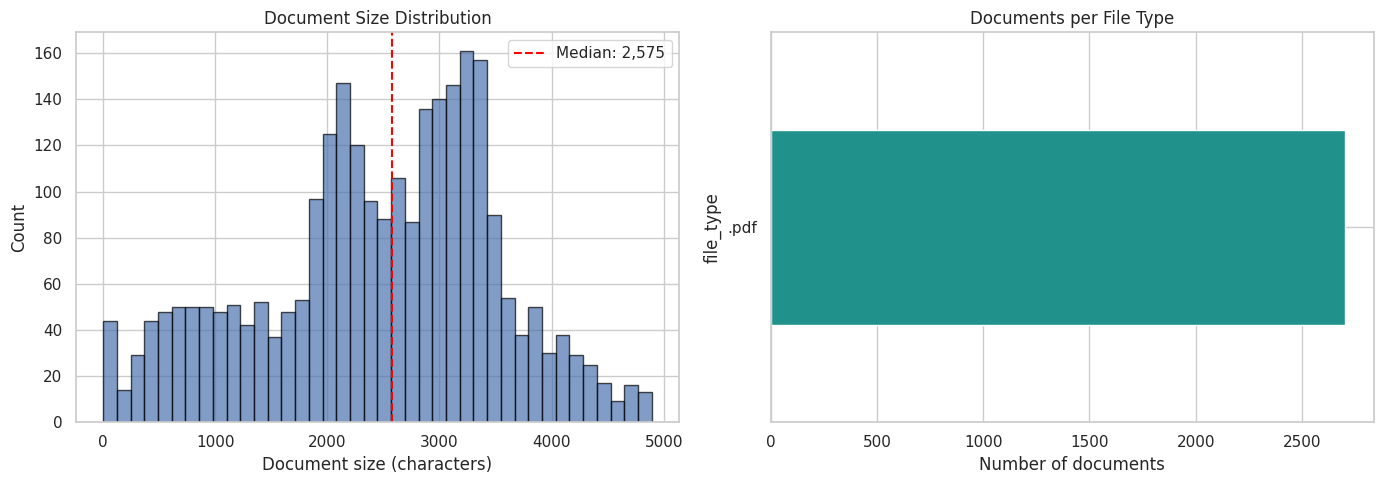

In [5]:
# Distribution of document sizes
data = df_explore["chars"]
data = data[data < data.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of document sizes
axes[0].hist(data, bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Document size (characters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Document Size Distribution")
axes[0].axvline(data.median(), color="red", linestyle="--", label=f"Median: {data.median():,.0f}")
axes[0].legend()

# Documents per file type
type_counts = df_explore["file_type"].value_counts()
type_counts.plot.barh(ax=axes[1], color=sns.color_palette("viridis", len(type_counts)))
axes[1].set_xlabel("Number of documents")
axes[1].set_title("Documents per File Type")

plt.tight_layout()
plt.show()

In [6]:
# Source file breakdown
src_counts = df_explore["source"].value_counts()
print(f"Total unique source files: {len(src_counts)}")
print(src_counts.head(10).to_string())

Total unique source files: 6
source
13.Machine-Learning-Systems.pdf    2604
2605.11505v2.pdf                     29
2605.03299v1.pdf                     19
2605.01386v1.pdf                     19
2605.12288v2.pdf                     17
2605.01205v1.pdf                     15


---
## 3. Cleaning the Corpus

Raw text extracted from PDFs, PPTX, and DOCX files often contains noise:
- **Page numbers**: Standalone numbers from PDF extraction
- **Slide markers**: 'Slide N' labels from PowerPoint conversion
- **Excessive whitespace**: Multiple blank lines from formatting

We apply `clean_corpus()` from `src/ingestion/cleaners.py` to strip this before chunking.

In [7]:
cleaned_docs, clean_stats = clean_corpus(docs, min_content_length=50)

print("Cleaning results:")
print(f"  Before: {clean_stats['original_count']} docs, {clean_stats['original_total_chars']:,} chars")
print(f"  After:  {clean_stats['cleaned_count']} docs, {clean_stats['cleaned_total_chars']:,} chars")
print(f"  Dropped: {clean_stats['dropped_count']} docs (too short after cleaning)")
reduction = 1 - clean_stats['cleaned_total_chars'] / max(clean_stats['original_total_chars'], 1)
print(f"  Size reduction: {reduction:.1%}")

Cleaning results:
  Before: 2703 docs, 6,697,234 chars
  After:  2666 docs, 6,694,816 chars
  Dropped: 37 docs (too short after cleaning)
  Size reduction: 0.0%


In [8]:
# Compare before/after for a sample document
if len(docs) > 0:
    from src.ingestion.cleaners import clean_document
    sample_doc = docs[0]
    print(f"Sample document: {sample_doc.metadata.get('source', '?')} [{sample_doc.metadata.get('file_type', '?')}]")
    print(f"  Before cleaning: {len(sample_doc.page_content):,} chars")

    cleaned_sample = clean_document(sample_doc)
    print(f"  After cleaning:  {len(cleaned_sample.page_content):,} chars")
    print(f"\nFirst 500 chars after cleaning:")
    print(cleaned_sample.page_content[:500])
else:
    print("No documents loaded. Place lecture notes in data/lectures/ first.")

Sample document: 13.Machine-Learning-Systems.pdf [.pdf]
  Before cleaning: 59 chars
  After cleaning:  59 chars

First 500 chars after cleaning:
Machine Learning
Systems Vijay
Janapa Reddi
Introduction to


In [9]:
# Cleaned corpus stats
if len(cleaned_docs) > 0:
    print("Cleaned corpus breakdown:")
    df_cleaned = pd.DataFrame([
        {
            "source": d.metadata.get("source", "unknown"),
            "file_type": d.metadata.get("file_type", "unknown"),
            "chars": len(d.page_content),
        }
        for d in cleaned_docs
    ])
    display(df_cleaned.groupby("file_type").agg(
        count=("chars", "count"),
        total_chars=("chars", "sum"),
        avg_chars=("chars", "mean"),
    ).sort_values("count", ascending=False))
else:
    print("No cleaned documents available.")

Cleaned corpus breakdown:


,count,total_chars,avg_chars
file_type,,,
.pdf,2666,6694816,2511.183796


---
## 4. Chunking - Naive Baseline

We use `RecursiveCharacterTextSplitter` with the default config:
- `chunk_size=1000`
- `chunk_overlap=200`
- Separators: `["\n\n", "\n", " ", ""]`

This is a deliberate baseline - Phase 2 will compare multiple strategies.

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(cleaned_docs)
print(f"Documents: {len(cleaned_docs)} -> Chunks: {len(chunks)}")
print(f"Average expansion ratio: {len(chunks)/len(cleaned_docs):.1f}x")

Documents: 2666 -> Chunks: 9137
Average expansion ratio: 3.4x


In [11]:
# Chunk size statistics
stats = chunk_stats_table(chunks)
display(stats)

,chars
metric,
count,9137
mean,842
std,221
min,1
25%,797
50%,950
75%,977
max,1000


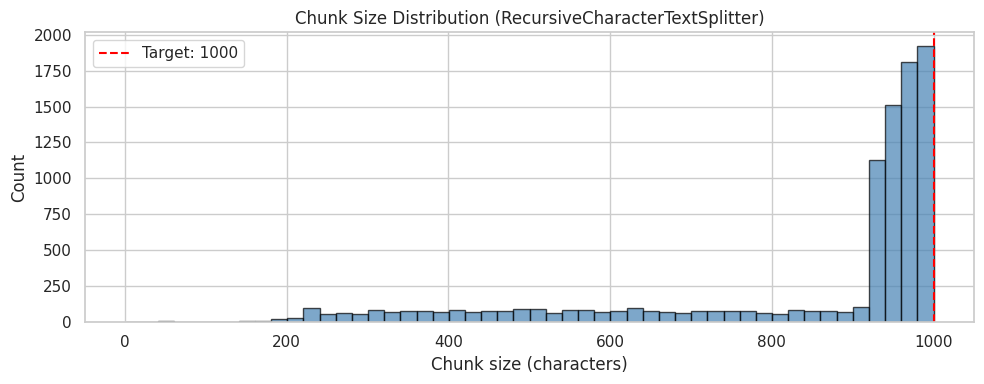

In [12]:
# Chunk size distribution
chunk_sizes = [len(c.page_content) for c in chunks]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(chunk_sizes, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(CHUNK_SIZE, color="red", linestyle="--", label=f"Target: {CHUNK_SIZE}")
ax.set_xlabel("Chunk size (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution (RecursiveCharacterTextSplitter)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Preview a few chunks to sanity-check quality
print("=" * 60)
for i in [0, len(chunks)//2, len(chunks)-1]:
    print(f"\n--- Chunk {i} (from: {chunks[i].metadata.get('source', '?')}) ---")
    print(chunks[i].page_content[:400])
    print(f"... [{len(chunks[i].page_content)} chars]")
    print()


--- Chunk 0 (from: 13.Machine-Learning-Systems.pdf) ---
Machine Learning
Systems Vijay
Janapa Reddi
Introduction to
... [59 chars]


--- Chunk 4568 (from: 13.Machine-Learning-Systems.pdf) ---
module has well-defined responsibilities and limited external assumptions, are
far more resilient to change.
Encapsulation also supports dependency awareness, reducing the likelihood
of undeclared consumers silently reusing outputs or internal representations.
This is especially important in feedback-prone systems, where hidden depen-
dencies can introduce behavioral drift over time. Exposing outp
... [994 chars]


--- Chunk 9136 (from: 2605.12288v2.pdf) ---
t .
C.3.2. HYPERPARAMETERS.
We train TBPO on 4 H100 GPUs with batch size 32 and max response length 2048, using RMSProp with a cosine
learning-rate schedule (warmup ratio 0.05), lr 5×10 −7, for 1 epoch. Unless stated otherwise, we use β= 0.1 and Bregman
parametersλ= 0ands= 4.
... [276 chars]



---
## 5. Embedding & Indexing in ChromaDB

We embed all chunks with `nomic-embed-text` via Ollama and store them in a persistent ChromaDB collection.

> **Prerequisite:** Ollama must be running with the model pulled:
> ```bash
> ollama pull nomic-embed-text
> ```

In [14]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Quick sanity check - embed a single sentence
test_vec = embeddings.embed_query("Hello world")
print(f"Embedding dimension: {len(test_vec)}")
print(f"First 5 values: {test_vec[:5]}")

Embedding dimension: 768
First 5 values: [-0.0067923986, 0.031049244, -0.15565781, 0.03668334, 0.02271188]


In [15]:
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION_NAME = "course_qa_naive"

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
print(f"Persist directory: {PERSIST_DIR}")
print(f"Collection: {COLLECTION_NAME}")
print("This may take several minutes depending on your hardware.")
print()

start_time = time.perf_counter()

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=PERSIST_DIR,
    collection_name=COLLECTION_NAME,
)

indexing_time = time.perf_counter() - start_time

print(f"Indexing completed in {indexing_time:.1f}s")
print(f"Total vectors: {vectorstore._collection.count()}")

Indexing 9137 chunks into ChromaDB...
Persist directory: /home/hunganh/Code/Python/course_qa_assist/vectorstore/chroma_db
Collection: course_qa_naive
This may take several minutes depending on your hardware.

Indexing completed in 59.5s
Total vectors: 9137


---
## 6. Validation - Sanity-Check Queries

We test the index with 5 questions to qualitatively verify that retrieval works.
For each query we check:
- Are the retrieved documents relevant?
- Do the source URLs make sense?
- Are the similarity scores reasonable?

In [16]:
# Validation queries based on the 5 research papers
VALIDATION_QUERIES = [
    "What is Span Representation Alignment and how does it improve knowledge distillation?",
    "How does MemORAI organize and retrieve memory for LLM conversational agents?",
    "What is the LLM-XTM framework and how does it handle cross-lingual topic modeling?",
    "How does Selective Off-Policy Reference Tuning address zero-reward prompts in GRPO?",
    "What is TokenRatio and how does it decompose sequence-level preferences to token level?",
]

In [17]:
# Run each query and display results
for query in VALIDATION_QUERIES:
    result = timed_retrieval(vectorstore, query, k=5)
    display_retrieval_results(
        query,
        list(zip(result.docs, result.scores)),
        max_content_chars=250,
    )
    print(f"  ⏱ Latency: {result.latency_ms:.1f} ms")
    print()

  ⏱ Latency: 21.5 ms



  ⏱ Latency: 17.7 ms



  ⏱ Latency: 20.9 ms



  ⏱ Latency: 18.2 ms



  ⏱ Latency: 18.1 ms



In [18]:
# Summary table of all queries
benchmark_df = benchmark_queries(vectorstore, VALIDATION_QUERIES, k=5)
display(benchmark_df)

,query,num_results,top_score,avg_score,latency_ms,top_source
0,What is Span Representation Alignment and how does it improve knowledge dist...,5,0.543658,0.569381,20.7,13.Machine-Learning-Systems.pdf
1,How does MemORAI organize and retrieve memory for LLM conversational agents?,5,0.548444,0.605224,21.8,2605.01386v1.pdf
2,What is the LLM-XTM framework and how does it handle cross-lingual topic mod...,5,0.345848,0.393745,18.8,2605.03299v1.pdf
3,How does Selective Off-Policy Reference Tuning address zero-reward prompts i...,5,0.584950,0.648618,16.2,2605.11505v2.pdf
4,What is TokenRatio and how does it decompose sequence-level preferences to t...,5,0.417722,0.472350,16.9,2605.12288v2.pdf


---
## 7. Baseline Metrics Summary

Let's record all the key metrics from this Phase 1 baseline.

In [19]:
metrics = IndexingMetrics(
    num_raw_docs=len(docs),
    num_chunks=len(chunks),
    chunk_sizes=[len(c.page_content) for c in chunks],
    indexing_time_s=indexing_time,
)

summary = metrics.summary()
summary["cleaned_docs"] = len(cleaned_docs)
summary["dropped_docs"] = clean_stats["dropped_count"]
summary["embedding_model"] = "nomic-embed-text"
summary["embedding_dim"] = len(test_vec)
summary["chunk_strategy"] = "RecursiveCharacterTextSplitter"
summary["chunk_size"] = CHUNK_SIZE
summary["chunk_overlap"] = CHUNK_OVERLAP
summary["avg_retrieval_latency_ms"] = round(benchmark_df["latency_ms"].mean(), 1)

print("Phase 1 - Baseline Metrics")
print("=" * 40)
for k, v in summary.items():
    print(f"  {k:30s}: {v}")

Phase 1 - Baseline Metrics
  raw_documents                 : 2703
  chunks                        : 9137
  avg_chunk_chars               : 842
  min_chunk_chars               : 1
  max_chunk_chars               : 1000
  indexing_time_s               : 59.49
  cleaned_docs                  : 2666
  dropped_docs                  : 37
  embedding_model               : nomic-embed-text
  embedding_dim                 : 768
  chunk_strategy                : RecursiveCharacterTextSplitter
  chunk_size                    : 1000
  chunk_overlap                 : 200
  avg_retrieval_latency_ms      : 18.9


In [20]:
# Save metrics to results/
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

metrics_path = results_dir / "phase1_indexing_baseline.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Metrics saved to {metrics_path}")

Metrics saved to /home/hunganh/Code/Python/course_qa_assist/results/phase1_indexing_baseline.json


---
## 8. Reloading the Vector Store

Since ChromaDB is persisted to disk, we can reload it in future notebooks without re-indexing.

In [21]:
# Example: reloading the existing vector store
vectorstore_reloaded = Chroma(
    persist_directory=PERSIST_DIR,
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
)

print(f"Reloaded collection: {vectorstore_reloaded._collection.count()} vectors")

# Verify it works
test_results = vectorstore_reloaded.similarity_search("What is knowledge distillation?", k=3)
print(f"Test query returned {len(test_results)} results")
for i, doc in enumerate(test_results, 1):
    print(f"  {i}. {doc.metadata.get('source', '?')} ({len(doc.page_content)} chars)")

Reloaded collection: 9137 vectors
Test query returned 3 results
  1. 13.Machine-Learning-Systems.pdf (980 chars)
  2. 13.Machine-Learning-Systems.pdf (995 chars)
  3. 13.Machine-Learning-Systems.pdf (937 chars)


## Observations & Next Steps

### What we built
- A functional RAG index using `RecursiveCharacterTextSplitter` + `nomic-embed-text` + ChromaDB
- Baseline metrics on 2,703 raw docs (2,666 cleaned) and 9,137 chunks

### What to observe
- The corpus loads 2,703 raw documents and keeps 2,666 after cleaning (37 dropped).
- The average chunk size is 842 chars, which is close to our 1000 char target.
- The expansion ratio is about 3.4x (2,666 docs -> 9,137 chunks).
- Indexing took 59.5s and average retrieval latency is 18.9 ms.
- Our naive approach doesn't leverage the structure of the source documents (sections, headers).

### Next: Phase 2 - Chunking Strategies (`02_chunking_strategies.ipynb`)
We will compare different chunking approaches including academic-aware splitting:
1. Fixed-size character splitting
2. Recursive character splitting (current baseline)
3. Token-based splitting
4. Markdown-aware splitting
5. Semantic splitting

Each will be evaluated to identify the best strategy for research papers.
